<a href="https://colab.research.google.com/github/ashaw23871/power-plant-energy-prediction-ann/blob/main/ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd

In [23]:
df = pd.read_csv("/content/drive/MyDrive/powerplant_data.csv")

In [24]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [25]:
# AT => Temperature
# V => Vacuum
# AP => pressure
# PH => humidity
# PE => power emitted

In [26]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [27]:
X = df.drop("PE",axis=True)
y = df["PE"]

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
import torch
import torch.nn as nn

In [31]:
y_train.shape

(7654,)

In [32]:
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [33]:
from torch.utils.data import TensorDataset,DataLoader

In [34]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [35]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

In [36]:
X_train_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

Deep Learning

In [37]:
# Define our ann model
class ANN(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        # 1st layer
        nn.Linear(in_features = X_train.shape[1],out_features=6),
        nn.ReLU(),

        # 2nd layer
        nn.Linear(6,6),
        nn.ReLU(),

        #output layer
        nn.Linear(6,1)
    )

  def forward(self,x):
    return self.model(x)

In [38]:
import torch.optim as optim

model = ANN()

#loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [39]:
# Training ann model
training_loss=[]
val_loss=[]

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
  model.train()

  running_loss = 0.0

  for xb,yb in train_loader:
    optimizer.zero_grad()

    outputs = model(xb)
    loss = criterion(outputs,yb)
    loss.backward() #back propagation: compute gradient
    optimizer.step() #update parameters

    running_loss += loss.item()

  epoch_train_loss = running_loss/len(train_loader)
  training_loss.append(epoch_train_loss)


  #validate
  model.eval()

  running_val_loss=0.0

  with torch.no_grad():
    for xb,yb in test_loader:
      outputs = model(xb)
      loss = criterion(outputs,yb)

      running_val_loss += loss.item()

    epoch_val_loss = running_val_loss/len(test_loader)
    val_loss.append(epoch_val_loss)

    print(f"For epoch {epoch+1}/{epochs} --> training loss = {epoch_train_loss} and validation loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
      best_val_loss = epoch_val_loss
      torch.save(model.state_dict(),"best_model.pth")






For epoch 1/100 --> training loss = 206287.03984375 and validation loss = 204711.61770833333
For epoch 2/100 --> training loss = 200148.84739583332 and validation loss = 192595.16171875
For epoch 3/100 --> training loss = 178944.14772135418 and validation loss = 161749.60390625
For epoch 4/100 --> training loss = 139849.26539713543 and validation loss = 115940.49153645833
For epoch 5/100 --> training loss = 92414.598046875 and validation loss = 69805.56295572917
For epoch 6/100 --> training loss = 52457.67412109375 and validation loss = 37887.141829427084
For epoch 7/100 --> training loss = 29203.741149902344 and validation loss = 22691.663525390624
For epoch 8/100 --> training loss = 19353.11298014323 and validation loss = 16782.123876953126
For epoch 9/100 --> training loss = 15206.274287923177 and validation loss = 13732.743986002604
For epoch 10/100 --> training loss = 12551.52084757487 and validation loss = 11381.875170898438
For epoch 11/100 --> training loss = 10312.369673665364

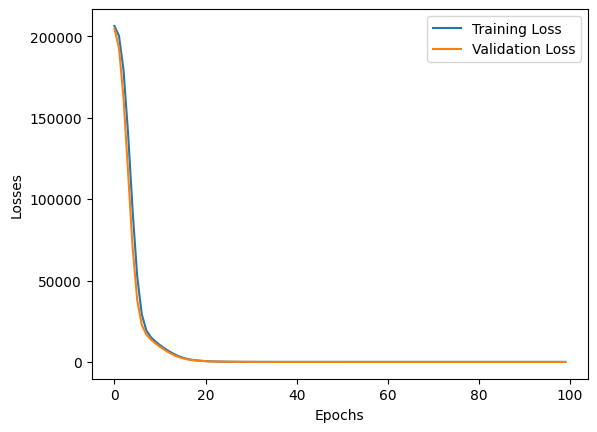

In [40]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "Training_Loss" : training_loss,
    "Validation_Loss" : val_loss
})

plt.plot(loss_df["Training_Loss"],label="Training Loss")
plt.plot(loss_df["Validation_Loss"],label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [42]:
#Loading the best model
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [44]:
# Evaluation

model.eval()

with torch.no_grad():
  train_predict = model(X_train_tensor)
  test_predict = model(X_test_tensor)


  train_mse_loss = criterion(train_predict,y_train_tensor)
  test_mse_loss = criterion(test_predict,y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.253246307373047
Testing MSE: 18.59134292602539


In [45]:
from sklearn.metrics import r2_score
print("r2_score = ",r2_score(y_test_tensor,test_predict))

r2_score =  0.9350280447740834


In [60]:
actual = pd.DataFrame(y_test.values,columns=["Actual Values"])

predicted = pd.DataFrame(test_predict,columns=["Predicted Values"])

pd.concat([actual,predicted],axis=1)

,Actual Values,Predicted Values
0,433.27,435.016937
1,438.16,436.422363
2,458.42,461.752686
3,480.82,476.842010
4,441.41,435.091980
...,...,...
1909,456.70,451.376556
1910,438.04,431.202179
1911,467.80,467.858154
1912,437.14,430.544830
